# LakeShore 330 온도/전압 로거 — Python 포트 (v4)

## 개요

이 노트북은 저온물성 실험에서 **LakeShore 330 온도 컨트롤러**의 절대온도(K)와 원시 센서 전압(V)을
일정한 간격으로 읽어 CSV/Excel로 기록하고, 실시간으로 이중(dual) 그래프를 그려주는 로거를 다룹니다.

원래는 MATLAB으로 작성된 `LakeShore330v4.m` 이었고, 이후 동일한 동작을 하는 Python 스크립트
`LakeShore330v4.py` 로 이식되었습니다. 이 노트북은 그 `LakeShore330v4.py` 를 셀 단위로 잘게 나누고,
각 부분이 **무엇을, 왜** 하는지 한글로 상세히 설명을 붙인 학습/실행용 버전입니다.
스크립트 자체의 동작(로직)은 전혀 바꾸지 않았습니다 — 단지 셀과 설명으로 재구성한 것뿐입니다.

## 핵심 아키텍처 3가지

1. **영구 상태 머신 (Persistent State Machine)** — `BufferManager` 클래스가 측정값을 메모리에
   모아두다가(batch), 일정 개수가 쌓이면 한 번에 디스크에 기록합니다. 프로그램이 끝날 때는
   `rescue()` 를 호출해 남은 데이터를 마지막까지 안전하게 구조(rescue)합니다.
2. **내결함성 실시간 플로팅 (Fault-tolerant Live Plotting)** — 실험 도중 그래프 창을 닫아도
   로깅 자체는 계속되고, 프로그램 종료 시 `system_cleanup()` 이 열려있던 창을 저장하거나,
   창이 이미 닫혀있으면 CSV 파일로부터 그래프를 headless(화면 없이)로 재구성해 저장합니다.
3. **동적 이동 윈도우 변화율 추적 (Dynamic Moving-Window Rate Tracking)** — 매 측정마다
   `DIFF_WINDOW_SEC` 초 전 온도와 비교해 순간 변화율 ΔT를 계산합니다. 타임스탬프가 항상
   증가한다는 성질을 이용해 매번 처음부터 찾지 않고 포인터를 앞으로만 이동시키는
   **이중 포인터(two-pointer) 알고리즘**으로 계산 비용을 O(1) 상각(amortized)으로 줄였습니다.

## 노트북 구성

1. 의존성 설치 확인
2. 모듈 임포트 및 한글 폰트 설정
3. 설정 플래그 (Configuration Flags)
4. 사용자 정의 예외 클래스
5. `BufferManager` — 영구 메모리 계층
6. 데이터 수집 함수 (실제 하드웨어 / 모의 데이터)
7. 하드웨어 초기화 함수
8. 동적 윈도우 문자열 빌더
9. 통합 정리(Cleanup) 매니저
10. 메인 로깅 루프 (`main` 함수)
11. 실행 방법 및 주의사항 (Jupyter 환경 특이사항 포함)
12. (부록) 모의 데이터 곡선 미리보기


## 1. 의존성 설치

이 노트북을 실행하려면 아래 패키지가 필요합니다.

| 패키지 | 용도 |
|---|---|
| `pandas` | 측정 데이터를 표(DataFrame) 형태로 다루고 CSV/Excel로 저장 |
| `matplotlib` | 실시간 이중 그래프(절대온도 / ΔT) 그리기 |
| `openpyxl` | `pandas.to_excel()` 이 `.xlsx` 파일을 쓸 때 사용하는 엔진 |
| `pyvisa` | GPIB/VISA로 실제 LakeShore 330 하드웨어와 통신 (`USE_SIMULATION = False` 일 때만 필요) |
| `scipy` | 선택사항. CSV 기록이 실패했을 때 비상 데이터를 `.mat` 로 저장하는 데 사용 (없으면 자동으로 `.pkl` 로 대체) |
| `ipympl` | 선택사항이지만 **Jupyter에서 실시간 그래프 갱신을 보려면 사실상 필수** (11절에서 자세히 설명) |

이미 설치되어 있다면 아래 셀은 건너뛰어도 됩니다.


In [1]:
# 필요한 패키지가 없다면 주석을 해제하고 실행하세요.
%pip install -q pandas matplotlib openpyxl pyvisa scipy ipympl


Note: you may need to restart the kernel to use updated packages.


## 2. 모듈 임포트 및 한글 폰트 설정

표준 라이브러리(`math`, `os`, `random`, `time`, `datetime`)와 `pandas`, `matplotlib` 을 불러옵니다.

한 가지 눈여겨볼 부분은 **한글 폰트 설정**입니다. matplotlib 의 기본 폰트(`DejaVu Sans`)에는
한글 글리프가 없어서, 그래프 제목/축 라벨에 한글을 그대로 쓰면 `□□□` 같은 빈 사각형(tofu)으로
표시됩니다. 이를 막기 위해 시스템에 설치된 폰트 목록을 조회해서 `AppleGothic`
(macOS), `Apple SD Gothic Neo`, `Malgun Gothic`(Windows), `NanumGothic` 순서로
사용 가능한 첫 번째 한글 폰트를 찾아 `matplotlib.rcParams['font.family']` 에 지정합니다.
또한 `axes.unicode_minus = False` 를 설정해, 한글 폰트로 바꿨을 때 마이너스(`-`) 기호가
깨지는 것을 방지합니다.

> 원본 MATLAB 스크립트에는 이 폰트 문제가 없었습니다(MATLAB 그래픽 엔진은 기본적으로
> 시스템 한글 폰트를 사용). Python으로 이식하면서 **동일한 결과물**(한글이 정상적으로 보이는 그래프)을
> 만들기 위해 추가된 부분입니다.


In [2]:
import math
import os
import random
import time
from datetime import datetime, timedelta

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure

# 한글 라벨/제목이 플롯에 정상적으로 렌더링되도록 시스템 폰트 지정 (없으면 기본 폰트로 대체)
_installed_fonts = {f.name for f in fm.fontManager.ttflist}
for _candidate in ('AppleGothic', 'Apple SD Gothic Neo', 'Malgun Gothic', 'NanumGothic'):
    if _candidate in _installed_fonts:
        plt.rcParams['font.family'] = _candidate
        break
plt.rcParams['axes.unicode_minus'] = False


## 3. 설정 플래그 (Configuration Flags)

프로그램 최상단에서 동작을 결정하는 4개의 상수입니다. 실험 목적에 맞게 이 값들만 바꾸면 되고,
나머지 코드는 건드릴 필요가 없도록 설계되어 있습니다 (원본 MATLAB 스크립트와 동일한 설계 의도).

| 플래그 | 기본값 | 의미 |
|---|---|---|
| `USE_SIMULATION` | `True` | `True`면 가상의 냉각 곡선(모의 데이터)을 생성하고, `False`면 GPIB로 실제 장비와 통신 |
| `LOOP_INTERVAL_SEC` | `1.0` | 목표 샘플링 주기(초). 매 반복마다 이 간격을 지키려고 시도 |
| `DIFF_WINDOW_SEC` | `20.0` | ΔT(변화율)를 계산할 때 비교할 "몇 초 전" 값의 기준. 예: 900이면 15분 전 대비 변화량 |
| `BATCH_THRESHOLD` | `30` | 메모리에 몇 개의 측정행(row)을 모았다가 한 번에 디스크에 쓸지 결정 (I/O 횟수를 줄이기 위함) |

`DIFF_WINDOW_SEC` 값이 60의 배수인지 아닌지에 따라 뒤에 나올 `build_window_strings()` 함수가
"20초" 또는 "15분"처럼 사람이 읽기 좋은 문자열을 자동으로 만들어 줍니다.


In [3]:
# 1. 설정 플래그 (Configuration Flags)
USE_SIMULATION = True        # 실제 하드웨어 DAQ를 사용할 경우 False로 설정
LOOP_INTERVAL_SEC = 1.0      # 엄격한 샘플링 간격 목표 (초 단위, 가변 가능)
DIFF_WINDOW_SEC = 20.0       # 온도 차이를 계산할 윈도우 간격 (초 단위, 예: 15분 = 900)
BATCH_THRESHOLD = 30         # 디스크 I/O 전 메모리에 유지할 데이터 행(row)의 수


## 4. 사용자 정의 예외 클래스

MATLAB 원본은 `error('LakeShore330:DeadConnection', ...)` 와
`error('LakeShore330:HardwareFailure', ...)` 처럼 **식별자(identifier)가 있는 에러**를 던져서,
호출하는 쪽에서 어떤 종류의 실패인지 구분할 수 있게 했습니다.

Python에서는 이를 두 개의 전용 예외 클래스로 옮겼습니다.

- `LakeShore330DeadConnectionError` — 장비는 연결되었지만 응답이 비어있거나 숫자로 해석할 수
  없을 때 (예: 케이블은 꽂혀 있는데 장비 전원이 꺼져 있는 경우)
- `LakeShore330HardwareFailureError` — GPIB 연결 자체, 혹은 초기화 시퀀스 중 어느 단계에서든
  실패했을 때의 포괄적 에러

일반적인 `Exception` 대신 이렇게 이름이 있는 예외를 쓰면, 나중에 이 로거를 더 큰 자동화
파이프라인에 통합할 때 `except LakeShore330DeadConnectionError:` 처럼 원인별로 다르게
대응(재시도, 알림 전송 등)할 수 있습니다.


In [4]:
class LakeShore330DeadConnectionError(Exception):
    pass


class LakeShore330HardwareFailureError(Exception):
    pass


## 5. `BufferManager` — 영구 메모리 계층

MATLAB 원본에서는 `persistent` 키워드로 선언된 지역 변수(`dataBuffer`, `bIndex`, `batchLimit`,
`targetFile`)가 함수 호출 사이에도 값을 유지하는 "영구 상태 머신" 역할을 했습니다
(`BufferManager('init', ...)`, `BufferManager('add', ...)`, `BufferManager('rescue', ...)`
처럼 액션 이름으로 분기하는 하나의 함수였습니다).

Python에는 `persistent` 변수가 없으므로, 같은 역할을 **클래스 인스턴스의 속성(attribute)**으로
옮겼습니다. `BufferManager` 객체 하나가 곧 MATLAB의 `persistent` 상태에 해당합니다.

### 메서드별 역할

- **`init(batch_limit, target_file, window_str_eng)`** — 새 로깅 세션을 시작할 때 한 번 호출.
  배치 크기, 저장할 CSV 파일 경로, 그리고 ΔT 컬럼의 동적 이름(`dT_dt_20sec`처럼 윈도우 길이가
  이름에 포함됨)을 설정하고 내부 버퍼를 비웁니다.
- **`add(log_number, timestamp, temp_k, sensor_v, dT_dt)`** — 측정 1건을 내부 리스트(`self.buffer`)에
  쌓습니다. 쌓인 개수가 `batch_limit`(`BATCH_THRESHOLD`)에 도달하면 자동으로 `_flush()` 를 호출해
  디스크에 씁니다. → 매번 디스크에 쓰지 않고 모아서 쓰기 때문에 I/O 횟수가 크게 줄어듭니다.
- **`_flush()`** — 버퍼에 쌓인 행들을 `pandas.DataFrame` 으로 변환한 뒤 CSV에 이어쓰기(append)
  합니다. 파일이 아직 없으면(`os.path.isfile` 이 `False`) 헤더를 포함해서 새로 만들고, 있으면
  헤더 없이 이어붙입니다 (MATLAB의 `writetable(..., 'WriteMode', 'append')` 와 동일한 패턴).
- **`rescue()`** — 프로그램이 끝날 때(정상 종료든, 에러든, Ctrl+C든) **반드시** 호출되는 안전망입니다.
  1. 아직 디스크에 쓰지 못한 나머지 버퍼가 있으면 CSV에 마저 기록합니다.
  2. 만약 그 마지막 기록마저 실패하면(디스크 꽉 참, 권한 문제 등), 데이터를 잃지 않도록
     `scipy` 가 있으면 `EMERGENCY_DUMP.mat` 로, 없으면 `EMERGENCY_DUMP.pkl` 로 비상 저장합니다.
  3. CSV 기록이 성공적이면, 전체 CSV를 다시 읽어 `.xlsx` 사본을 만들어 둡니다
     (실험 종료 후 엑셀로 바로 열어볼 수 있게 하기 위함).

이 클래스는 데이터 유실을 최우선으로 막도록 설계되어 있습니다 — 어떤 이유로 프로그램이
죽더라도 최소한 CSV(혹은 최악의 경우 비상 덤프 파일) 안에 지금까지의 측정값이 남아있도록 합니다.


In [5]:
# =========================================================================
# 격리된 버퍼 매니저 (영구 메모리 계층)
# =========================================================================
class BufferManager:
    def __init__(self):
        self.buffer = []
        self.batch_limit = None
        self.target_file = None
        self.dynamic_col_name = None
        self.columns = None

    def init(self, batch_limit, target_file, window_str_eng):
        self.batch_limit = batch_limit
        self.target_file = target_file
        self.dynamic_col_name = f'dT_dt_{window_str_eng}'
        self.columns = ['Log_Number', 'Timestamp', 'Temperature_K', 'Sensor_V', self.dynamic_col_name]
        self.buffer = []

    def add(self, log_number, timestamp, temp_k, sensor_v, dT_dt):
        self.buffer.append({
            'Log_Number': log_number,
            'Timestamp': timestamp.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
            'Temperature_K': temp_k,
            'Sensor_V': sensor_v,
            self.dynamic_col_name: dT_dt,
        })

        if len(self.buffer) >= self.batch_limit:
            self._flush()

    def _flush(self):
        if not self.buffer:
            return
        batch_df = pd.DataFrame(self.buffer, columns=self.columns)
        write_header = not os.path.isfile(self.target_file)
        batch_df.to_csv(self.target_file, mode='a', header=write_header, index=False)
        self.buffer = []

    def rescue(self):
        print('\n\n--- 실험 종료 / 중단 신호 감지됨 ---')
        if self.target_file is None:
            return

        csv_write_success = False
        if self.buffer:
            try:
                self._flush()
                csv_write_success = True
            except Exception:
                rescue_df = pd.DataFrame(self.buffer, columns=self.columns)
                try:
                    from scipy.io import savemat
                    savemat('EMERGENCY_DUMP.mat', {col: rescue_df[col].to_numpy() for col in rescue_df.columns})
                except ImportError:
                    rescue_df.to_pickle('EMERGENCY_DUMP.pkl')
        else:
            if os.path.isfile(self.target_file):
                csv_write_success = True

        if csv_write_success:
            try:
                excel_file = self.target_file.replace('.csv', '.xlsx')
                final_data = pd.read_csv(self.target_file)
                final_data.to_excel(excel_file, index=False)
            except Exception:
                pass

        self.buffer = []
        self.batch_limit = None
        self.target_file = None


## 6. 데이터 수집 함수 (실제 하드웨어 / 모의 데이터)

측정값을 얻는 방법은 두 가지이며, `USE_SIMULATION` 플래그에 따라 둘 중 하나가 선택됩니다.

### `read_data_real(instr)` — 실제 하드웨어

GPIB/VISA 연결 객체(`instr`)에 `CDAT?`(온도 조회), `SDAT?`(원시 센서 전압 조회) 명령을 순서대로
보내고 응답을 `float` 로 변환합니다. 통신 중 어떤 예외가 발생하든(타임아웃, 파싱 실패 등)
`(NaN, NaN)` 을 반환하도록 넓게 `except`를 걸어두었는데, 이는 **한 번의 통신 실패 때문에
전체 로깅 루프가 멈추는 것을 막기 위함**입니다. NaN은 이후 CSV/그래프에 자연스럽게 결측치로
남게 됩니다.

### `read_data_mock(elapsed_time)` — 모의(시뮬레이션) 데이터

실제 냉각 실험을 흉내 내는 물리 모델입니다.

- **지수 감쇠 냉각 곡선**: `idealTemp = (T_start - T_base) * exp(-elapsed_time / tau) + T_base`
  - `T_start = 300.0 K` : 초기 온도(상온 근처)
  - `T_base = 16.0 K` : 최종 도달 온도(예: 액체 헬륨 근처 극저온)
  - `tau = 1800.0 초` : 시간 상수(냉각이 얼마나 빠른지). 약 30분 만에 63%가량 냉각되는 속도.
- **열 잡음(thermal noise)**: 표준정규분포(`random.gauss(0, 1)`)에 0.05~0.10 사이의 무작위
  스케일을 곱해 더합니다 — 실제 센서에서 관찰되는 온도 요동을 흉내냅니다.
- **온도→전압 선형 보정식**: `idealVoltage = -0.00176 * tempK + 1.02816` — 실제 다이오드/저항
  온도 센서가 갖는 대략적인 선형 응답 특성을 반영한 가상의 보정 계수입니다.
- **전기 잡음(electrical noise)**: 표준정규분포에 작은 스케일(0.0001V)을 곱해 전압에 더합니다.

이 모의 함수 덕분에 실제 장비 없이도 `USE_SIMULATION = True` 상태로 전체 파이프라인
(로깅 → 배치 저장 → 실시간 플롯 → 정리)을 그대로 테스트해볼 수 있습니다.


In [6]:
# =========================================================================
# 로컬 데이터 수집 함수 (분리된 계층)
# =========================================================================
def read_data_real(instr):
    try:
        instr.write('CDAT?')
        temp_k = float(instr.read())
        instr.write('SDAT?')
        sensor_v = float(instr.read())
    except Exception:
        temp_k = float('nan')
        sensor_v = float('nan')
    return temp_k, sensor_v


def read_data_mock(elapsed_time):
    T_start = 300.0
    T_base = 16.0
    tau = 1800.0

    ideal_temp = (T_start - T_base) * math.exp(-elapsed_time / tau) + T_base
    thermal_noise = random.gauss(0, 1) * (0.05 + random.random() * 0.05)
    temp_k = ideal_temp + thermal_noise

    ideal_voltage = (-0.00176 * temp_k) + 1.02816
    electrical_noise = random.gauss(0, 1) * 0.0001
    sensor_v = ideal_voltage + electrical_noise

    return temp_k, sensor_v


## 7. 하드웨어 초기화 함수 (`init_hardware`)

`USE_SIMULATION = False` 일 때만 호출되는 함수로, `pyvisa` 를 이용해 GPIB 주소
`GPIB0::12::INSTR` 에 연결하고 LakeShore 330의 두 디스플레이(Control / Sample)를
원하는 채널·단위로 세팅합니다. 타임아웃은 3000ms(3초)로 설정합니다.

### GPIB 명령어 의미

| 명령어 | 의미 |
|---|---|
| `CDAT?` | **Control** 디스플레이에 표시 중인 값을 조회 (여기서는 온도, 단위 K) |
| `CCHN A` | Control 디스플레이의 채널을 A로 설정 |
| `CUNI K` | Control 디스플레이의 단위를 켈빈(K)으로 설정 |
| `SCHN A` | **Sample** 디스플레이의 채널을 A로 설정 |
| `SUNI S` | Sample 디스플레이의 단위를 원시 센서 단위(S, 전압)로 설정 |
| `SDAT?` | Sample 디스플레이에 표시 중인 값을 조회 (여기서는 원시 전압) |

즉, **같은 센서(채널 A)를 두 디스플레이에 동시에 할당**하되, 한쪽은 온도(K)로, 다른 한쪽은
원시 전압(S) 단위로 보여주도록 설정합니다. 그래서 `CDAT?` 로는 온도를, `SDAT?` 로는 전압을
각각 얻을 수 있게 됩니다.

### 검증 핸드셰이크 (Verification Handshake)

연결 직후 `CDAT?` 를 한 번 보내보고, 응답이 비어있거나 숫자로 변환할 수 없으면
"장비는 연결되었지만 유효하지 않은 데이터를 반환했다"고 판단해
`LakeShore330DeadConnectionError` 를 던집니다. 이렇게 하면 케이블은 꽂혀 있지만 장비 전원이
꺼져 있거나 응답이 이상한 상태를, 초반에 빠르게 잡아낼 수 있습니다.

### `time.sleep(1.5)` 를 두 번 넣는 이유

채널/단위를 바꾼 직후 장비 내부적으로 디스플레이 값이 안정화되기까지 시간이 필요합니다
(LakeShore 330 매뉴얼에서 권장하는 대기 시간). 이 대기 없이 바로 다음 명령을 보내면
과도기적인(아직 갱신되지 않은) 값을 읽어올 위험이 있습니다.


In [7]:
# =========================================================================
# 하드웨어 초기화 (안전한 핸드셰이크 및 디스플레이 듀얼 라우팅)
# =========================================================================
def init_hardware():
    import pyvisa
    rm = pyvisa.ResourceManager()
    instr = rm.open_resource('GPIB0::12::INSTR')
    instr.timeout = 3000  # ms

    # 초기 검증 핸드셰이크 (Verification Handshake)
    instr.write('CDAT?')
    test_resp = instr.read().strip()
    try:
        valid = not math.isnan(float(test_resp))
    except ValueError:
        valid = False
    if not test_resp or not valid:
        raise LakeShore330DeadConnectionError('장비가 연결되었으나 유효하지 않은 데이터를 반환했습니다.')

    # 주 센서(Channel A 기준)를 두 디스플레이에 동시 할당
    instr.write('CCHN A')
    instr.write('CUNI K')
    time.sleep(1.5)  # 장비 내부 업데이트 사이클 대기 (매뉴얼 필수 권장사항)

    instr.write('SCHN A')
    instr.write('SUNI S')
    time.sleep(1.5)

    return instr


## 8. 동적 윈도우 문자열 빌더 (`build_window_strings`)

`DIFF_WINDOW_SEC` 값(초 단위)을 사람이 읽기 좋은 문자열로 바꿔주는 작은 유틸리티 함수입니다.

- 60의 배수이면(예: 900) → `"15분"`(한글 UI용) / `"15min"`(파일·컬럼명용, 영문+숫자만 사용)
- 60의 배수가 아니면(예: 20) → `"20초"` / `"20sec"`

두 가지 버전을 만드는 이유가 다릅니다.

- `window_str_kor` 는 콘솔 출력이나 그래프 제목처럼 **사람이 보는 곳**에 쓰입니다.
- `window_str_eng` 는 CSV 컬럼 이름(`dT_dt_20sec`)이나 파일명처럼 **프로그램이 다루는 값**에
  쓰이므로, 공백이나 한글 없이 안전한 문자만 사용합니다.

이 함수 덕분에 `DIFF_WINDOW_SEC` 하나만 바꿔도 UI 문구와 CSV 컬럼명이 자동으로 일관되게
따라 바뀝니다.


In [8]:
# =========================================================================
# 동적 파일명 및 UI/데이터 라벨 문자열 초기화
# =========================================================================
def build_window_strings(diff_window_sec):
    # 모듈로(mod) 연산을 통해 초 단위가 60의 배수인지 확인하여 UI 문자열 최적화
    if diff_window_sec % 60 == 0:
        minutes = int(diff_window_sec // 60)
        window_str_kor = f'{minutes}분'
        window_str_eng = f'{minutes}min'
    else:
        window_str_kor = f'{diff_window_sec:g}초'
        window_str_eng = f'{diff_window_sec:g}sec'
    return window_str_kor, window_str_eng


## 9. 통합 정리(Cleanup) 매니저 (`system_cleanup`)

이 함수는 메인 루프가 **어떤 이유로든 끝날 때** — 정상 종료, 예외 발생, 또는 사용자가
Ctrl+C(Jupyter에서는 정지 버튼)로 중단했을 때 — 마지막에 정확히 한 번 호출됩니다
(메인 루프의 `try/finally` 블록에서 보장). MATLAB 원본의 `onCleanup` 콜백과 동일한 역할입니다.

수행하는 일은 세 가지입니다.

1. **`buffer_manager.rescue()` 호출** — 메모리에 남아있는 마지막 데이터를 CSV에 마저 기록하고
   `.xlsx` 사본을 만듭니다 (5절 참고).
2. **그래프 이미지 저장 — 두 가지 경로 중 하나**
   - **그래프 창이 아직 열려 있으면**: 그 살아있는 Figure 객체를 그대로 `dpi=300`
     고해상도로 PNG에 저장합니다 (`fig.savefig(...)`).
   - **그래프 창이 이미 닫혀 있으면**: 화면에 그릴 창이 없으므로, 방금 완성된 CSV 파일을
     다시 읽어 들여 **headless(화면 없는) Figure** 를 새로 만들고, 그 위에 절대온도/ΔT
     그래프를 처음부터 다시 그려서 저장합니다. 이때 `matplotlib.figure.Figure` 를
     `pyplot` 없이 직접 생성하고 `FigureCanvasAgg` 를 연결하는데, 이렇게 하면 현재
     활성화된 백엔드가 무엇이든 상관없이 화면에 창을 띄우지 않고도 안전하게 이미지 파일만
     만들 수 있습니다.
   - 즉, **사용자가 실시간 그래프 창을 실수로(혹은 의도적으로) 닫아도 최종 결과 그래프는
     항상 남는다**는 것이 이 설계의 핵심입니다. 다만 로깅 자체는 창을 닫아도 멈추지
     않고 계속된다는 점은 유의하세요 (10절에서 다시 설명합니다).
3. **하드웨어 핸들 해제** — 실제 장비에 연결했었다면(`instr is not None`), `instr.close()` 로
   GPIB/VISA 세션을 명시적으로 닫아 다음 실행 때 "리소스 사용 중" 오류가 나지 않도록 합니다.


In [9]:
# =========================================================================
# 통합 정리 매니저 (Unified Cleanup Manager)
# =========================================================================
def system_cleanup(instr, fig, target_file, window_str_kor, window_str_eng, buffer_manager):
    buffer_manager.rescue()
    plot_filename = target_file.replace('.csv', '.png')
    dynamic_col_name = f'dT_dt_{window_str_eng}'

    fig_open = fig is not None and plt.fignum_exists(fig.number)

    if fig_open:
        print('[정보] 열려있는 피겨에서 고해상도 듀얼 플롯 이미지를 추출합니다...')
        try:
            fig.savefig(plot_filename, dpi=300)
            print(f'[성공] 최종 플롯 저장 완료: {plot_filename}')
        except Exception as e:
            print(f'[경고] 플롯 이미지 저장에 실패했습니다: {e}')
    else:
        print('[정보] 플롯 창이 닫혀있어 백그라운드에서 이중 플롯을 재생성하여 저장합니다...')
        try:
            if os.path.isfile(target_file):
                df = pd.read_csv(target_file, parse_dates=['Timestamp'])
                if len(df) > 0:
                    headless_fig = Figure(figsize=(8, 6))
                    FigureCanvasAgg(headless_fig)
                    ax1 = headless_fig.add_subplot(2, 1, 1)
                    ax2 = headless_fig.add_subplot(2, 1, 2, sharex=ax1)

                    ax1.plot(df['Timestamp'], df['Temperature_K'], '-o',
                              color=(0.8500, 0.3250, 0.0980), linewidth=1.5, markerfacecolor='r')
                    ax1.set_title('실시간 절대 온도 (Absolute Temperature)')
                    ax1.set_ylabel('온도 (K)')
                    ax1.grid(True)

                    ax2.plot(df['Timestamp'], df[dynamic_col_name], '-o',
                              color=(0.0, 0.4470, 0.7410), linewidth=1.5, markerfacecolor='b')
                    ax2.set_title(f'{window_str_kor} 온도 차이 (ΔT_{{{window_str_eng}}})')
                    ax2.set_xlabel('시간')
                    ax2.set_ylabel('ΔT (K)')
                    ax2.grid(True)

                    headless_fig.tight_layout()
                    headless_fig.savefig(plot_filename, dpi=300)
                    print(f'[성공] 백그라운드 듀얼 플롯 생성 및 저장 완료: {plot_filename}')
        except Exception as e:
            print(f'[경고] 백그라운드 플롯 복구 및 저장에 실패했습니다: {e}')

    if instr is not None:
        try:
            instr.close()
        except Exception:
            pass


## 10. 메인 로깅 루프 (`main` 함수)

지금까지 만든 부품들을 모두 조립하는 함수입니다. 실행 순서대로 설명합니다.

### 준비 단계

1. 현재 시각으로 `TempLog_YYYYMMDD_HHMMSS.csv` 파일명을 만듭니다.
2. `build_window_strings()` 로 한글/영문 윈도우 문자열을 만듭니다.
3. `USE_SIMULATION` 이 `False` 면 `init_hardware()` 로 실제 장비에 연결하고,
   실패하면 `LakeShore330HardwareFailureError` 로 감싸서 다시 던집니다.
4. `BufferManager` 인스턴스를 만들고 `init()` 으로 세션을 시작합니다.
5. 콘솔에 시작 배너와 컬럼 헤더를 출력합니다.
6. `matplotlib` 의 대화형 모드(`plt.ion()`)를 켜고, 위/아래로 나란한 두 개의 서브플롯
   (위: 절대온도, 아래: ΔT)을 가진 Figure를 만듭니다. 두 축은 `sharex=True` 로 x축(시간)을
   공유합니다 (MATLAB의 `linkaxes([ax1, ax2], 'x')` 와 동일한 효과).

### 무한 루프 (`while True`)

매 반복마다 다음을 수행합니다.

1. **시간 측정 시작** (`loop_start_time`) — 이번 반복이 얼마나 걸렸는지 재기 위함입니다.
2. **데이터 수집** — `USE_SIMULATION` 여부에 따라 `read_data_mock()` 또는 `read_data_real()` 호출.
3. **동적 이동 윈도우 기반 변화율(ΔT) 계산** — 이 노트북에서 가장 흥미로운 알고리즘 부분입니다.
   - 먼저 지금까지의 모든 시간·온도를 `time_data`, `temp_data` 리스트에 계속 추가합니다
     (이력을 전부 보관해야 그래프에 전체 궤적을 그릴 수 있기 때문).
   - 만약 로깅을 시작한 지 아직 `DIFF_WINDOW_SEC` 초가 지나지 않았다면 비교할 "과거" 데이터가
     없으므로 `dT_dt = NaN` 으로 둡니다.
   - `DIFF_WINDOW_SEC` 초가 지났다면, `DIFF_WINDOW_SEC` 초 전 시각(`target_time`)보다
     같거나 나중인 첫 번째 기록을 찾아 그때의 온도와 현재 온도의 차이를 구합니다.
   - **핵심 최적화**: 타임스탬프는 항상 증가하기만 하므로, 그 "과거 시점을 가리키는 포인터"
     (`window_ptr`)는 절대 뒤로 갈 필요가 없습니다. 그래서 매번 리스트 처음부터 다시 찾는 대신,
     이전 위치에서부터 `target_time` 을 넘어설 때까지만 앞으로 전진시킵니다. 그 결과 전체
     실행 시간 동안 포인터가 이동하는 총 횟수는 데이터 개수를 넘지 않으므로,
     반복당 비용이 **상각 O(1)** 이 됩니다 (매번 처음부터 훑는 O(n) 방식보다 장시간 실험에서
     훨씬 유리합니다).
4. **콘솔에 한 줄 출력** — 로그 번호, 타임스탬프, 온도, 전압, ΔT를 정렬된 표 형태로 출력합니다.
5. **버퍼에 push** — `buffer_manager.add(...)` 로 이번 측정을 버퍼 매니저에 넘깁니다
   (내부적으로 30개가 쌓이면 자동으로 CSV에 flush됨).
6. **그래프 갱신** — 그래프 창이 아직 열려 있으면(`plt.fignum_exists`) 두 라인의 데이터를
   갱신합니다. 다만 **매 반복마다 실제로 다시 그리지는 않고**, 첫 번째 샘플이거나 10개마다
   한 번씩만(`log_counter % 10 == 0`) x축 범위를 갱신하고 `plt.pause(0.001)` 로 화면을
   다시 그립니다 — 매번 다시 그리면 오히려 렌더링 비용 때문에 루프 타이밍이 흐트러지기
   때문에, 원본 MATLAB의 `drawnow` 호출 빈도를 그대로 유지한 것입니다.
7. **간격 보정** — 이번 반복에 실제로 걸린 시간(`execution_time`)을 측정해서,
   `LOOP_INTERVAL_SEC` 에서 그만큼을 뺀 나머지 시간만 `time.sleep()` 합니다. 이렇게 하면
   데이터 처리나 그래프 갱신에 시간이 조금 걸리더라도 전체 주기가 목표 간격(기본 1초)에서
   크게 벗어나지 않습니다.

### 왜 무한 루프인가?

원본 MATLAB 코드의 `while isLogging` 도 `isLogging` 을 다시 `false` 로 바꾸는 코드가 어디에도
없어서, 사실상 무한 루프였습니다 (오직 Ctrl+C 또는 에러로만 종료). 이 Python 버전도 동일하게
`while True` 로 두어 **원래 동작을 그대로 유지**했습니다. 종료는 `KeyboardInterrupt`
(터미널의 Ctrl+C, Jupyter의 정지 버튼)로만 이루어지며, `try ... finally` 구조 덕분에 어떤 식으로
루프가 끝나든 `system_cleanup()` 이 반드시 실행되어 데이터와 그래프가 안전하게 저장됩니다.


In [10]:
# =========================================================================
# 메인 로깅 루프
# =========================================================================
def main():
    # 2. 동적 파일명 및 UI/데이터 라벨 문자열 초기화
    timestamp_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'TempLog_{timestamp_str}.csv'
    window_str_kor, window_str_eng = build_window_strings(DIFF_WINDOW_SEC)

    # 3. 안전한 핸드셰이크 및 디스플레이 듀얼 라우팅을 통한 하드웨어 초기화
    instr = None
    if not USE_SIMULATION:
        try:
            instr = init_hardware()
        except Exception as e:
            raise LakeShore330HardwareFailureError(
                f'LakeShore 330 연결 및 초기화에 실패했습니다.\n{e}'
            ) from e
        hw_status = '실제 하드웨어 (LakeShore 330 듀얼 라우팅 완료)'
    else:
        hw_status = '시뮬레이션 모드 (가상 데이터)'

    # 4. 절대적인 데이터 및 하드웨어 보호 (버퍼 매니저 초기화 - 동적 컬럼명 전달)
    buffer_manager = BufferManager()
    buffer_manager.init(BATCH_THRESHOLD, filename, window_str_eng)

    # 5. 터미널 UI 및 그래픽 플롯 초기화
    print('\n=======================================================================')
    print('                 LakeShore330 DAQ 시스템 시작됨 (v4.2)               ')
    print('=======================================================================')
    print(f'대상 파일 : {filename}')
    print(f'하드웨어  : {hw_status}')
    print(f'윈도우 간격: {window_str_kor} ({DIFF_WINDOW_SEC:g} 초)')
    print('-----------------------------------------------------------------------')
    print(f"{'로그 #':<8} | {'타임스탬프':<23} | {'온도 (K)':<10} | {'전압 (V)':<10} | {window_str_kor} 변화율(K)")
    print('-----------------------------------------------------------------------')

    plt.ion()
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
    try:
        fig.canvas.manager.set_window_title('LakeShore330 실시간 모니터')
    except Exception:
        pass

    live_plot1, = ax1.plot([], [], '-o', color=(0.8500, 0.3250, 0.0980), linewidth=1.5, markerfacecolor='r')
    ax1.set_title('실시간 절대 온도 (Absolute Temperature)')
    ax1.set_ylabel('온도 (K)')
    ax1.grid(True)

    live_plot2, = ax2.plot([], [], '-o', color=(0.0, 0.4470, 0.7410), linewidth=1.5, markerfacecolor='b')
    ax2.set_title(f'{window_str_kor} 온도 차이 (ΔT_{{{window_str_eng}}})')
    ax2.set_xlabel('시간')
    ax2.set_ylabel('ΔT (K)')
    ax2.grid(True)

    fig.tight_layout()

    time_data = []
    temp_data = []
    rate_data = []
    window_ptr = 0  # 동적 이동 윈도우 포인터 (단조 증가, O(1) 상각 탐색용)

    log_counter = 0
    global_start_time = time.perf_counter()

    # 6. 메인 로깅 루프
    try:
        while True:
            loop_start_time = time.perf_counter()
            log_counter += 1

            current_datetime = datetime.now()
            elapsed_total_sec = time.perf_counter() - global_start_time

            if USE_SIMULATION:
                temp_k, sensor_v = read_data_mock(elapsed_total_sec)
            else:
                temp_k, sensor_v = read_data_real(instr)

            # =============================================================
            # 동적 이동 윈도우 기반 변화율 산출
            # =============================================================
            time_data.append(current_datetime)
            temp_data.append(temp_k)

            target_time = current_datetime - timedelta(seconds=DIFF_WINDOW_SEC)

            if (current_datetime - time_data[0]).total_seconds() < DIFF_WINDOW_SEC:
                dT_dt = float('nan')  # 윈도우 구간이 채워지지 않은 상태
            else:
                # 타임스탬프가 단조 증가하므로 포인터는 항상 전진만 하면 됨 (상각 O(1))
                while time_data[window_ptr] < target_time:
                    window_ptr += 1
                dT_dt = temp_k - temp_data[window_ptr]

            rate_data.append(dT_dt)
            # =============================================================

            current_str = current_datetime.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]
            print(f'{log_counter:<10d} | {current_str:<23s} | {temp_k:<10.4f} | {sensor_v:<10.6f} | {dT_dt:<15.4f}')

            # 동적 변수도 순차적으로 버퍼에 푸시됨
            buffer_manager.add(log_counter, current_datetime, temp_k, sensor_v, dT_dt)

            if plt.fignum_exists(fig.number):
                live_plot1.set_data(time_data, temp_data)
                live_plot2.set_data(time_data, rate_data)

                if log_counter == 1 or log_counter % 10 == 0:
                    ax1.set_xlim(time_data[0], time_data[-1] + timedelta(seconds=LOOP_INTERVAL_SEC))
                    ax1.relim()
                    ax1.autoscale_view(scalex=False)
                    ax2.relim()
                    ax2.autoscale_view(scalex=False)
                    plt.pause(0.001)

            execution_time = time.perf_counter() - loop_start_time
            time_remaining = max(0.0, LOOP_INTERVAL_SEC - execution_time)
            time.sleep(time_remaining)
    finally:
        system_cleanup(instr, fig, filename, window_str_kor, window_str_eng, buffer_manager)


## 11. 실행 방법 및 주의사항

### ⚠️ Jupyter에서 실시간 그래프를 보려면 백엔드를 바꿔야 합니다

Jupyter 노트북의 **기본 그래프 백엔드는 `inline`** 인데, 이 백엔드는 셀이 끝날 때 그림을
한 장의 정적 이미지로만 보여줄 뿐, `main()` 이 실행되는 동안 실시간으로 갱신되는 모습을
보여주지 못합니다. `.py` 스크립트를 터미널에서 직접 실행할 때는 OS의 GUI 백엔드
(macOS의 `macosx`, Windows의 `TkAgg`/`QtAgg` 등)를 사용하기 때문에 실시간 갱신이 자연스럽게
보였지만, 노트북 안에서는 별도 설정이 필요합니다.

- **권장: `ipympl` 설치 후 `%matplotlib widget`** — 노트북 안에 실시간으로 갱신되는
  대화형 그래프가 그대로 임베드됩니다. (1절에서 이미 설치했다면 바로 아래 셀만 실행하면 됩니다.)
- **대안: `%matplotlib qt`** — 별도의 OS 창으로 그래프를 띄웁니다 (로컬 Jupyter에서만 동작,
  원격/클라우드 환경에서는 사용 불가할 수 있음).
- 아무 것도 하지 않으면(`inline` 그대로) 로깅과 CSV/Excel 저장은 정상적으로 동작하지만,
  그래프는 실시간으로 보이지 않고 **종료 후 저장된 `.png` 파일**로만 확인할 수 있습니다.

### 실행 방법

1. 아래 `%matplotlib widget` 셀을 실행합니다 (한 번만 실행하면 됩니다).
2. 그 다음 셀에서 `main()` 을 호출하면 로깅이 시작됩니다. 콘솔 출력과 실시간 그래프가
   함께 나타납니다.

### 중단(종료) 방법

`main()` 은 **의도적으로 무한 루프**이므로 (10절 참고), 실험을 끝내려면 직접 중단시켜야 합니다.

- Jupyter 툴바의 **정지(interrupt) 버튼(■)** 을 클릭하거나, `Kernel ▸ Interrupt` 메뉴를 선택하세요.
  이는 터미널의 Ctrl+C와 동일하게 `KeyboardInterrupt` 를 발생시킵니다.
- 인터럽트가 발생하면 `main()` 내부의 `finally` 블록이 실행되어 `system_cleanup()` 이 호출되고,
  지금까지의 데이터가 CSV/Excel로 안전하게 저장되며, 그래프도 PNG로 저장됩니다.
- 노트북 셀 실행창에 `KeyboardInterrupt` 트레이스백이 표시되는 것은 **정상**입니다 — 데이터는
  이미 그 이전에 안전하게 저장된 뒤입니다.

### 결과 파일

실행 후 노트북과 같은 폴더에 아래 3개 파일이 `TempLog_<시작시각>` 이름으로 생성됩니다.

| 파일 | 내용 |
|---|---|
| `TempLog_YYYYMMDD_HHMMSS.csv` | 전체 원본 측정 데이터 (로그번호, 타임스탬프, 온도, 전압, ΔT) |
| `TempLog_YYYYMMDD_HHMMSS.xlsx` | 위 CSV를 그대로 엑셀로 변환한 사본 |
| `TempLog_YYYYMMDD_HHMMSS.png` | 종료 시점의 이중(절대온도/ΔT) 그래프 고해상도(300dpi) 이미지 |

### 실제 하드웨어로 전환하려면

3절의 `USE_SIMULATION` 을 `False` 로 바꾸고, `pyvisa` 와 사용 중인 OS에 맞는 VISA 백엔드
(NI-VISA, 혹은 순수 Python 구현체인 `pyvisa-py`)가 설치되어 있어야 하며, LakeShore 330이
`GPIB0::12::INSTR` 주소로 연결되어 있어야 합니다.


In [11]:
# Jupyter에서 실시간으로 갱신되는 그래프를 보려면 아래를 실행하세요.
# (ipympl이 설치되어 있지 않다면 위 1절의 설치 셀에서 ipympl을 함께 설치하세요.)
%matplotlib widget

# 원격/클라우드 환경 등에서 ipympl을 쓸 수 없다면 아래처럼 inline으로 대체할 수 있습니다.
# (실시간 갱신은 보이지 않고, 종료 후 저장된 .png로만 결과를 확인하게 됩니다.)
# %matplotlib inline


아래 셀을 실행하면 로깅이 시작됩니다. **중단하려면 Jupyter 툴바의 정지 버튼(■)을 누르세요.**



                 LakeShore330 DAQ 시스템 시작됨 (v4.2)               
대상 파일 : TempLog_20260711_023528.csv
하드웨어  : 시뮬레이션 모드 (가상 데이터)
윈도우 간격: 20초 (20 초)
-----------------------------------------------------------------------
로그 #     | 타임스탬프                   | 온도 (K)     | 전압 (V)     | 20초 변화율(K)
-----------------------------------------------------------------------
1          | 2026-07-11 02:35:28.051 | 300.1121   | 0.499886   | nan            


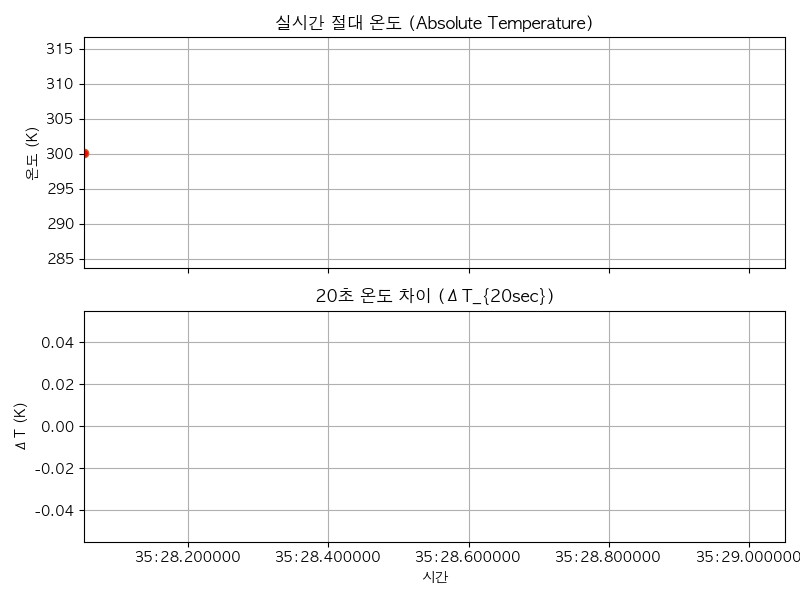

2          | 2026-07-11 02:35:29.056 | 299.8640   | 0.500653   | nan            
3          | 2026-07-11 02:35:30.059 | 299.7384   | 0.500593   | nan            
4          | 2026-07-11 02:35:31.063 | 299.5562   | 0.500893   | nan            
5          | 2026-07-11 02:35:32.068 | 299.2537   | 0.501569   | nan            
6          | 2026-07-11 02:35:33.068 | 299.0717   | 0.501616   | nan            
7          | 2026-07-11 02:35:34.073 | 299.0341   | 0.501599   | nan            
8          | 2026-07-11 02:35:35.078 | 298.7672   | 0.502391   | nan            
9          | 2026-07-11 02:35:36.080 | 298.7693   | 0.502481   | nan            
10         | 2026-07-11 02:35:37.081 | 298.5950   | 0.502612   | nan            


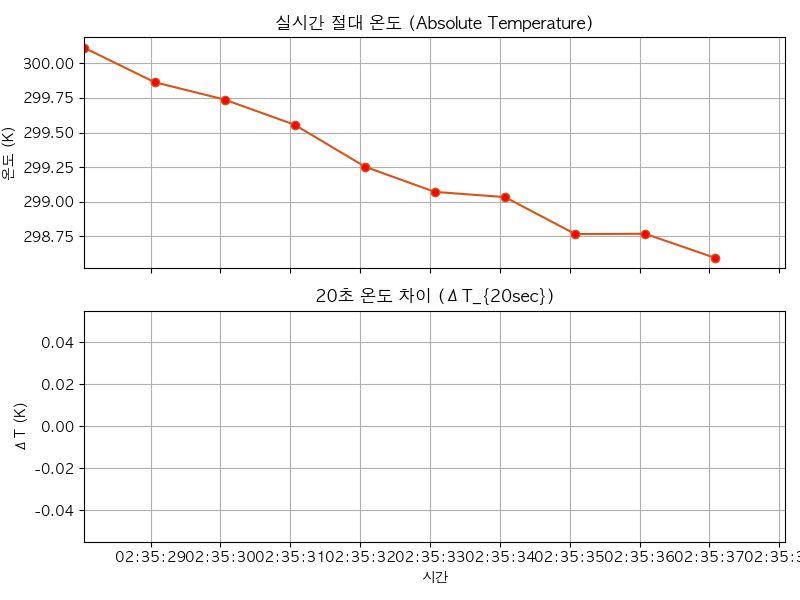

11         | 2026-07-11 02:35:38.086 | 298.3683   | 0.503168   | nan            
12         | 2026-07-11 02:35:39.091 | 298.3710   | 0.503000   | nan            
13         | 2026-07-11 02:35:40.096 | 298.1479   | 0.503618   | nan            
14         | 2026-07-11 02:35:41.101 | 297.9665   | 0.503697   | nan            
15         | 2026-07-11 02:35:42.105 | 297.7182   | 0.504128   | nan            
16         | 2026-07-11 02:35:43.106 | 297.6816   | 0.504368   | nan            
17         | 2026-07-11 02:35:44.111 | 297.5033   | 0.504499   | nan            
18         | 2026-07-11 02:35:45.114 | 297.4620   | 0.504506   | nan            
19         | 2026-07-11 02:35:46.116 | 297.0576   | 0.505442   | nan            
20         | 2026-07-11 02:35:47.121 | 296.9678   | 0.505247   | nan            


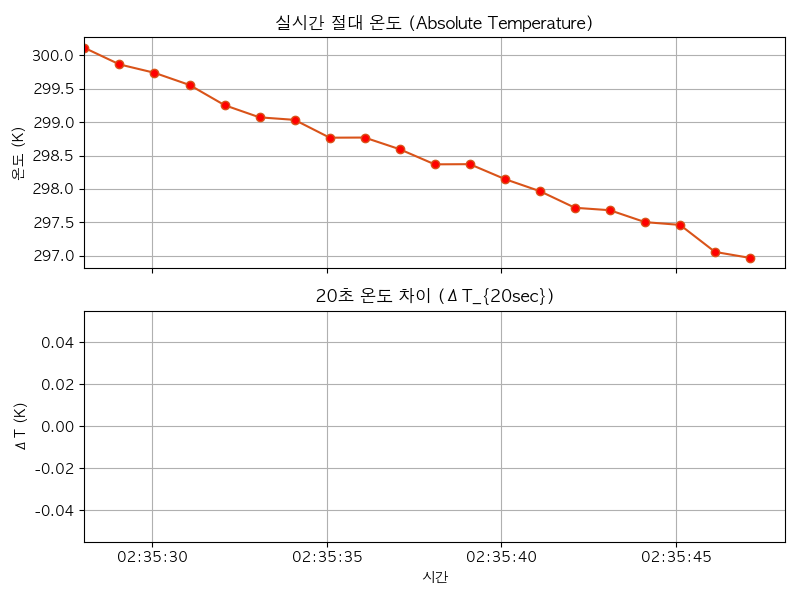

21         | 2026-07-11 02:35:48.126 | 296.9715   | 0.505530   | -2.8925        
22         | 2026-07-11 02:35:49.131 | 296.7612   | 0.505865   | -2.9771        
23         | 2026-07-11 02:35:50.136 | 296.6317   | 0.506059   | -2.9245        
24         | 2026-07-11 02:35:51.136 | 296.3811   | 0.506573   | -2.8726        
25         | 2026-07-11 02:35:52.138 | 296.1890   | 0.506910   | -2.8828        
26         | 2026-07-11 02:35:53.144 | 296.1434   | 0.506955   | -2.8906        
27         | 2026-07-11 02:35:54.147 | 295.9180   | 0.507333   | -2.8492        
28         | 2026-07-11 02:35:55.150 | 295.8403   | 0.507626   | -2.9290        
29         | 2026-07-11 02:35:56.155 | 295.5595   | 0.507900   | -3.0355        
30         | 2026-07-11 02:35:57.160 | 295.4705   | 0.508165   | -2.8978        


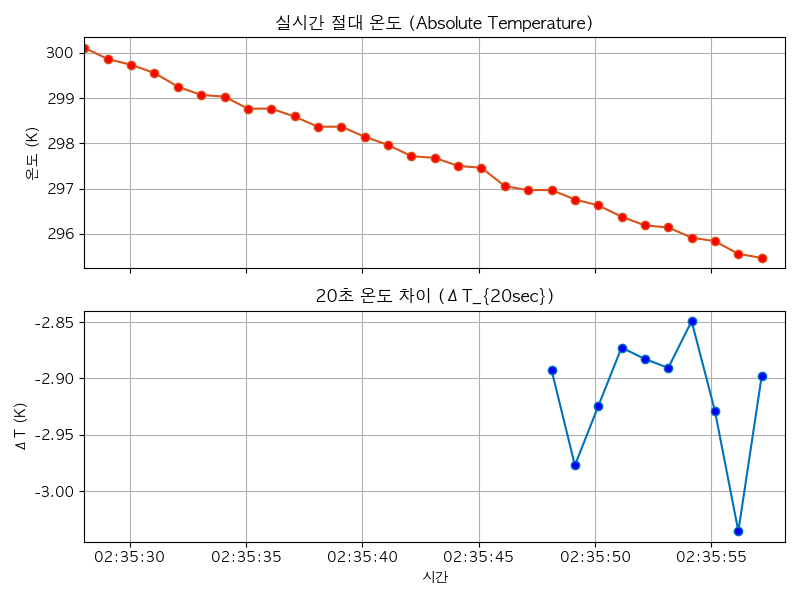

31         | 2026-07-11 02:35:58.165 | 295.1885   | 0.508728   | -3.1824        
32         | 2026-07-11 02:35:59.170 | 295.0897   | 0.508878   | -3.0582        
33         | 2026-07-11 02:36:00.172 | 294.9724   | 0.508892   | -2.9941        
34         | 2026-07-11 02:36:01.177 | 294.8031   | 0.509163   | -2.9151        
35         | 2026-07-11 02:36:02.181 | 294.6243   | 0.509755   | -3.0573        
36         | 2026-07-11 02:36:03.181 | 294.4459   | 0.510027   | -3.0574        
37         | 2026-07-11 02:36:04.181 | 294.3347   | 0.509984   | -3.1273        
38         | 2026-07-11 02:36:05.186 | 294.1831   | 0.510407   | -2.8744        
39         | 2026-07-11 02:36:06.189 | 294.1628   | 0.510466   | -2.8049        
40         | 2026-07-11 02:36:07.194 | 293.8883   | 0.510986   | -3.0831        


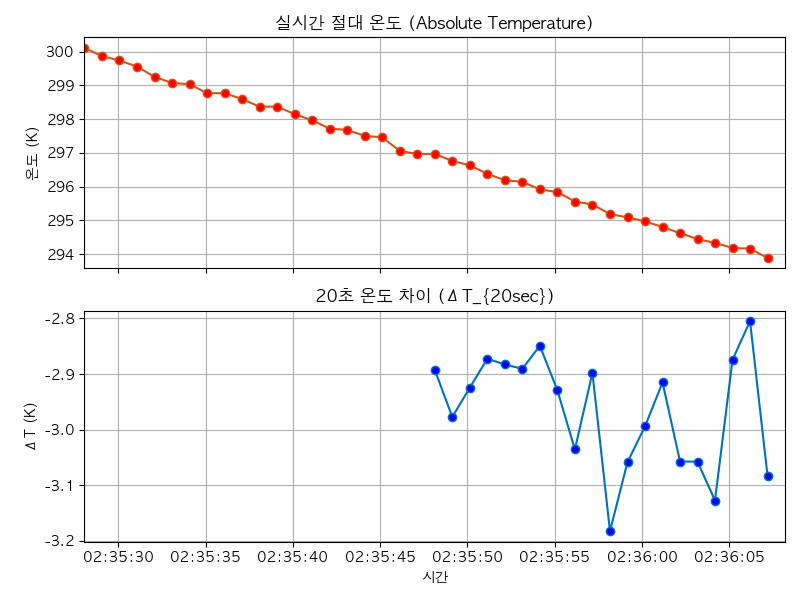

41         | 2026-07-11 02:36:08.199 | 293.6664   | 0.511197   | -3.0948        
42         | 2026-07-11 02:36:09.198 | 293.5812   | 0.511531   | -3.0505        
43         | 2026-07-11 02:36:10.203 | 293.6045   | 0.511588   | -2.7766        
44         | 2026-07-11 02:36:11.204 | 293.2599   | 0.511809   | -2.9291        
45         | 2026-07-11 02:36:12.208 | 293.0611   | 0.512338   | -3.0823        
46         | 2026-07-11 02:36:13.212 | 292.9906   | 0.512600   | -2.9274        
47         | 2026-07-11 02:36:14.215 | 292.8541   | 0.512768   | -2.9862        
48         | 2026-07-11 02:36:15.219 | 292.6636   | 0.513139   | -2.8959        
49         | 2026-07-11 02:36:16.224 | 292.5858   | 0.513317   | -2.8847        
50         | 2026-07-11 02:36:17.227 | 292.3128   | 0.513665   | -2.8758        


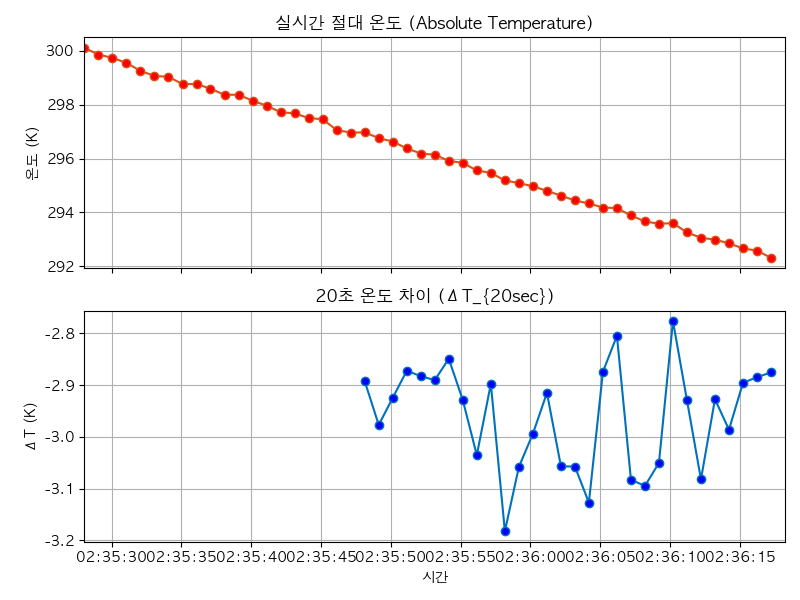

51         | 2026-07-11 02:36:18.232 | 292.1971   | 0.513870   | -2.8926        
52         | 2026-07-11 02:36:19.236 | 292.0059   | 0.514215   | -2.9666        
53         | 2026-07-11 02:36:20.237 | 291.8846   | 0.514720   | -2.9186        
54         | 2026-07-11 02:36:21.242 | 291.6753   | 0.514869   | -2.9490        
55         | 2026-07-11 02:36:22.243 | 291.6495   | 0.515061   | -2.7963        
56         | 2026-07-11 02:36:23.247 | 291.4301   | 0.515169   | -2.9046        
57         | 2026-07-11 02:36:24.252 | 291.1966   | 0.515658   | -2.9865        
58         | 2026-07-11 02:36:25.257 | 291.1802   | 0.515754   | -2.9826        
59         | 2026-07-11 02:36:26.262 | 290.8075   | 0.516315   | -3.0808        
60         | 2026-07-11 02:36:27.267 | 290.8037   | 0.516338   | -2.8627        


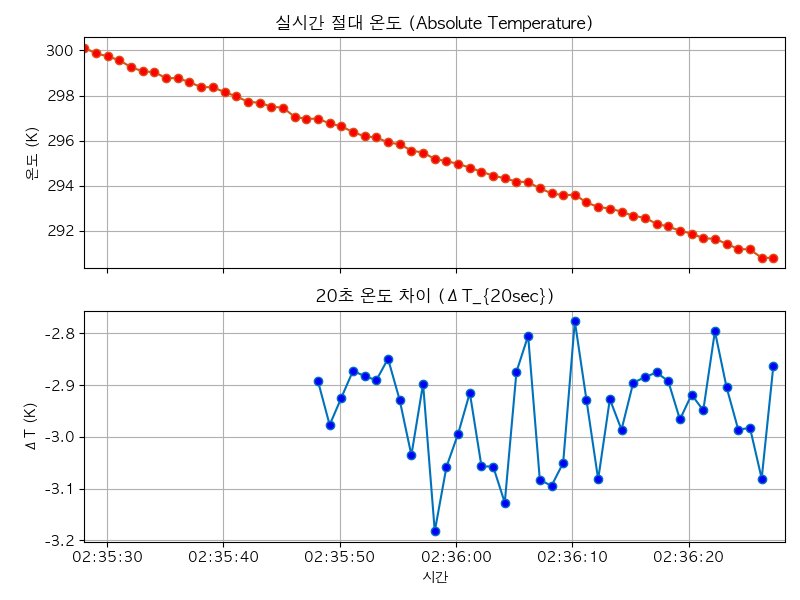

61         | 2026-07-11 02:36:28.272 | 290.6630   | 0.516651   | -2.9181        
62         | 2026-07-11 02:36:29.276 | 290.4478   | 0.517046   | -3.1567        
63         | 2026-07-11 02:36:30.281 | 290.4038   | 0.517137   | -2.8560        
64         | 2026-07-11 02:36:31.281 | 290.0985   | 0.517598   | -2.9627        
65         | 2026-07-11 02:36:32.282 | 290.0533   | 0.517617   | -2.9373        
66         | 2026-07-11 02:36:33.287 | 289.8902   | 0.517965   | -2.9638        
67         | 2026-07-11 02:36:34.292 | 289.7558   | 0.518110   | -2.9078        
68         | 2026-07-11 02:36:35.297 | 289.5559   | 0.518424   | -3.0299        
69         | 2026-07-11 02:36:36.302 | 289.3692   | 0.518845   | -2.9435        
70         | 2026-07-11 02:36:37.307 | 289.2751   | 0.518979   | -2.9220        


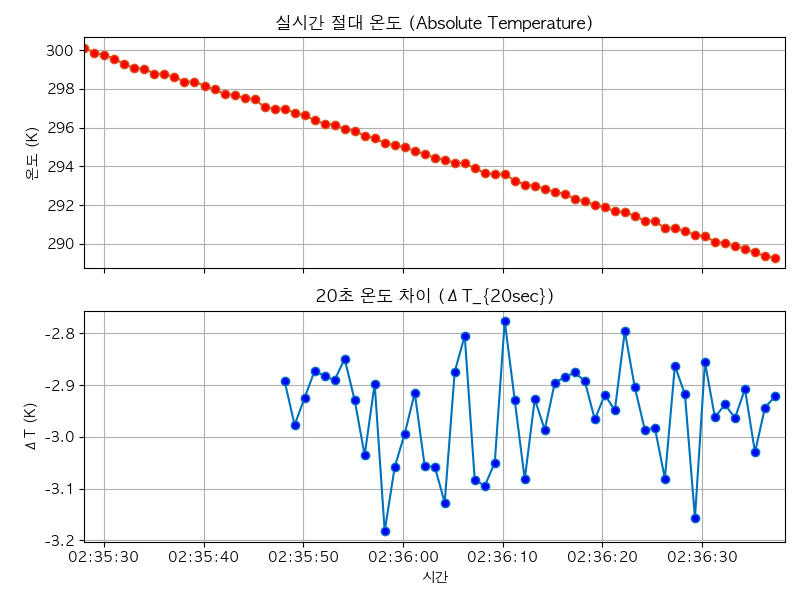

71         | 2026-07-11 02:36:38.312 | 289.1091   | 0.519279   | -2.8968        
72         | 2026-07-11 02:36:39.315 | 289.0204   | 0.519503   | -2.8642        
73         | 2026-07-11 02:36:40.319 | 288.8309   | 0.519620   | -2.8444        
74         | 2026-07-11 02:36:41.324 | 288.6292   | 0.520100   | -3.0204        
75         | 2026-07-11 02:36:42.326 | 288.5336   | 0.520424   | -2.8965        
76         | 2026-07-11 02:36:43.326 | 288.3902   | 0.520736   | -2.8064        
77         | 2026-07-11 02:36:44.331 | 288.2396   | 0.520744   | -2.9406        
78         | 2026-07-11 02:36:45.336 | 288.0793   | 0.521016   | -2.7282        
79         | 2026-07-11 02:36:46.341 | 287.8051   | 0.521563   | -2.9986        
80         | 2026-07-11 02:36:47.342 | 287.7381   | 0.521828   | -2.9249        


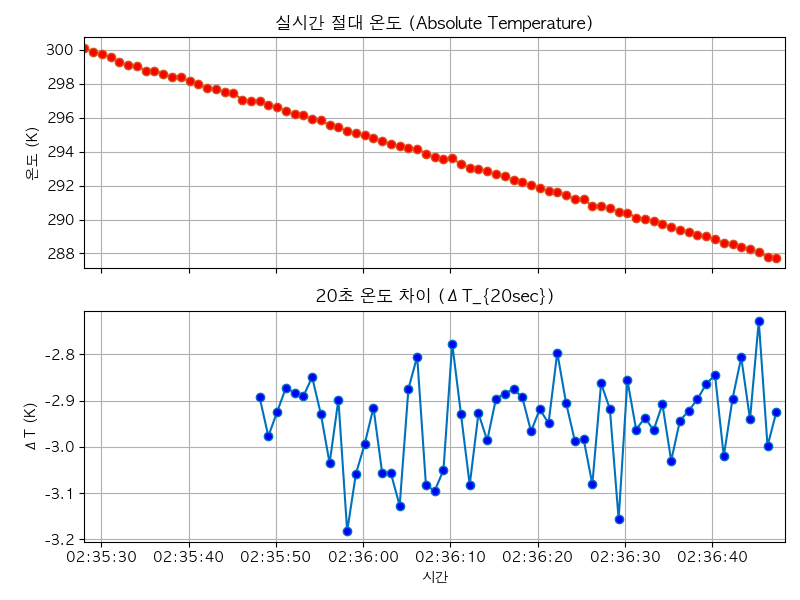

81         | 2026-07-11 02:36:48.347 | 287.6627   | 0.521807   | -2.7851        
82         | 2026-07-11 02:36:49.352 | 287.4406   | 0.522392   | -2.9632        
83         | 2026-07-11 02:36:50.357 | 287.3320   | 0.522176   | -2.7665        
84         | 2026-07-11 02:36:51.358 | 287.1925   | 0.522654   | -2.8608        
85         | 2026-07-11 02:36:52.363 | 287.0907   | 0.522821   | -2.7996        
86         | 2026-07-11 02:36:53.368 | 286.8447   | 0.523313   | -2.9112        
87         | 2026-07-11 02:36:54.371 | 286.6730   | 0.523672   | -2.8828        
88         | 2026-07-11 02:36:55.375 | 286.5242   | 0.523983   | -2.8450        
89         | 2026-07-11 02:36:56.381 | 286.3939   | 0.524229   | -2.8812        
90         | 2026-07-11 02:36:57.386 | 286.2042   | 0.524343   | -2.9049        


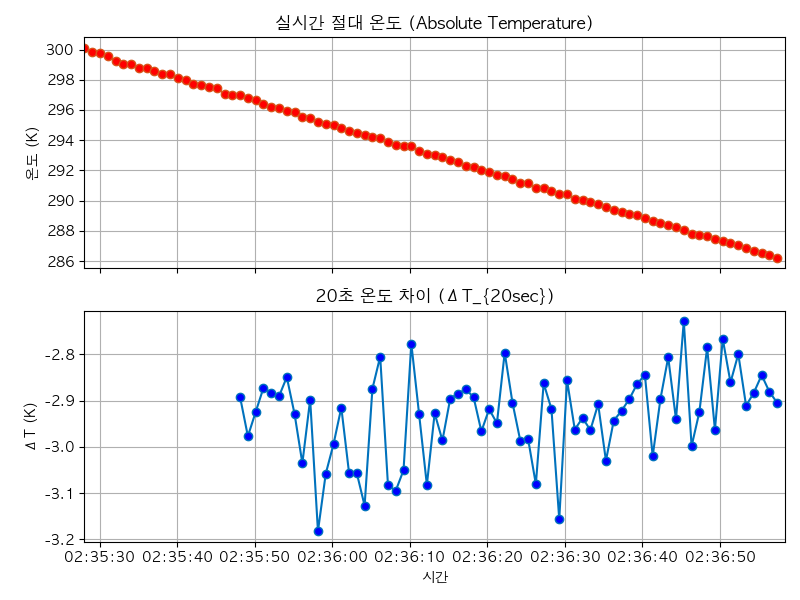

91         | 2026-07-11 02:36:58.391 | 286.1939   | 0.524491   | -2.8265        
92         | 2026-07-11 02:36:59.396 | 285.8723   | 0.525264   | -2.9586        
93         | 2026-07-11 02:37:00.401 | 285.8701   | 0.525075   | -2.7591        
94         | 2026-07-11 02:37:01.411 | 285.6701   | 0.525447   | -2.8635        
95         | 2026-07-11 02:37:02.416 | 285.4889   | 0.525694   | -2.9013        
96         | 2026-07-11 02:37:03.418 | 285.3154   | 0.525991   | -2.9242        
97         | 2026-07-11 02:37:04.423 | 285.2712   | 0.526034   | -2.8081        
98         | 2026-07-11 02:37:05.424 | 285.0303   | 0.526372   | -2.7748        
99         | 2026-07-11 02:37:06.429 | 284.8533   | 0.526869   | -2.8848        
100        | 2026-07-11 02:37:07.434 | 284.7287   | 0.526992   | -2.9340        


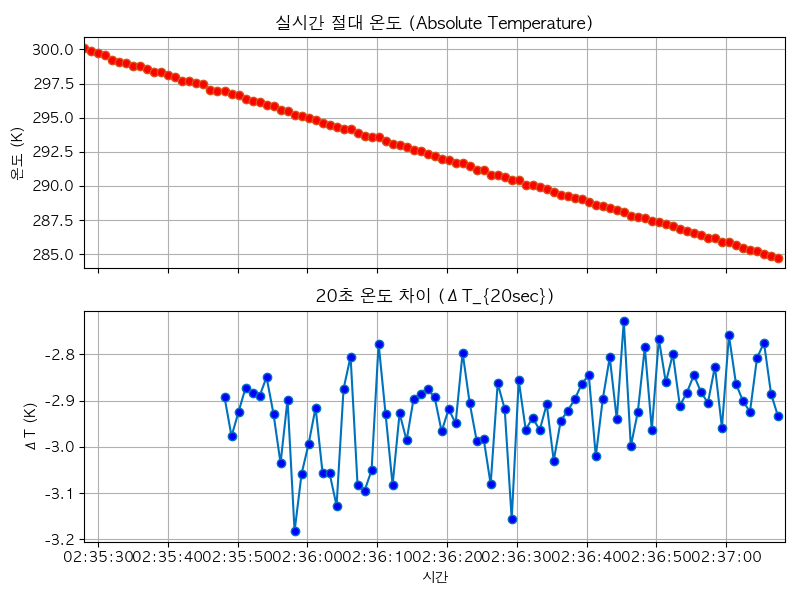



--- 실험 종료 / 중단 신호 감지됨 ---
[정보] 열려있는 피겨에서 고해상도 듀얼 플롯 이미지를 추출합니다...
[성공] 최종 플롯 저장 완료: TempLog_20260711_023528.png

[정보] 사용자에 의해 중단되었습니다 (Ctrl+C / 정지 버튼).


In [12]:
try:
    main()
except KeyboardInterrupt:
    print('\n[정보] 사용자에 의해 중단되었습니다 (Ctrl+C / 정지 버튼).')


## 12. (부록) 모의 데이터 곡선 미리보기

전체 로거를 실행하기 전에, `read_data_mock()` 이 어떤 냉각 곡선을 만들어내는지 정적인
그래프로 먼저 살펴보고 싶다면 아래 셀을 실행해보세요. 실제 로깅 루프를 돌리지 않고,
`elapsed_time` 값을 0초부터 몇 시간 뒤까지 미리 대입해보며 이론적인 온도·전압 곡선의
모양을 확인하는 용도입니다 (본 로거의 핵심 로직과는 무관한 **탐색용 보조 셀**입니다).


In [ ]:
import numpy as np

# 0초부터 3시간(10800초)까지, 10초 간격으로 이론적인 냉각 곡선을 미리 살펴봅니다.
preview_elapsed = np.arange(0, 10800, 10)
preview_temps = []
preview_volts = []
for t in preview_elapsed:
    tk, sv = read_data_mock(float(t))
    preview_temps.append(tk)
    preview_volts.append(sv)

fig_preview, (pax1, pax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
pax1.plot(preview_elapsed / 60.0, preview_temps, linewidth=1.2)
pax1.set_title('모의 데이터 미리보기: 절대 온도 (Absolute Temperature)')
pax1.set_ylabel('온도 (K)')
pax1.grid(True)

pax2.plot(preview_elapsed / 60.0, preview_volts, linewidth=1.2, color='tab:blue')
pax2.set_title('모의 데이터 미리보기: 센서 전압 (Sensor Voltage)')
pax2.set_xlabel('경과 시간 (분)')
pax2.set_ylabel('전압 (V)')
pax2.grid(True)

fig_preview.tight_layout()
plt.show()
